# Homework 0 | An Introduction To Python & The Four Horseman

My least favorite things about the classes I take now is that every professor seems to have the desire to want to teach Python over and over again completely from scratch. Luckily, I know you are all pretty smart, and I figured just throwing you guys into the deep end is probably the best way to get familar with Python and it's beautiful packages. Also, AI exists, which helps considerably.

Below are some introductory tasks that I think will get you very quickly familar with Python. Give them a go and try to rely on AI as minimally as possible - what I mean by that is, I expect that with practice, you should be able to do these things from memory + with your own thinking.

### 1. Stock Price Dashboard

Pull: Use yfinance to download daily data for a few tickers (e.g., AAPL, MSFT, TSLA).

Transform: Compute moving averages (20-day, 50-day, 200-day).

Plot: For each stock (on a seperate plot), overlay price and moving averages on a line chart. Hint: use matplotlib subplots

Extension: Compare multiple stocks on the same chart with normalized returns (so they start at 100).

### 2. Volatility & Returns Analysis

Pull: Grab 1–2 years of data for an ETF (like SPY).

Transform: Calculate daily returns, cumulative returns, and rolling volatility using returns and log returns. Hint: use .pct_change()

Plot:
* Histogram of daily returns (seaborn is great here).
* Rolling volatility over time.
* Cumulative return curve.

Extension: Compare volatility between two stocks or sectors.

### 3. Sector Comparison Project

Pull: Download sector ETFs (XLK, XLE, XLF, etc.) for the past 5 years.

Transform: Compute annualized returns and Sharpe ratios.

Plot:
* Heatmap of correlations between sector returns.
* Bar chart comparing average returns and volatilities.

Extension: Add rolling correlation plots (e.g., XLK vs SPY over time).

## Tips

* Use the yfinance package to pull data
* there is probably a function for "it" in pandas somewhere...
* Don't mess up!

## Your work starts here

/var/folders/8m/rcncq3bj137bqg7bk01pr0xw0000gn/T/ipykernel_34063/1316002855.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = "2020-01-01")['Close']
[*********************100%***********************]  3 of 3 completed


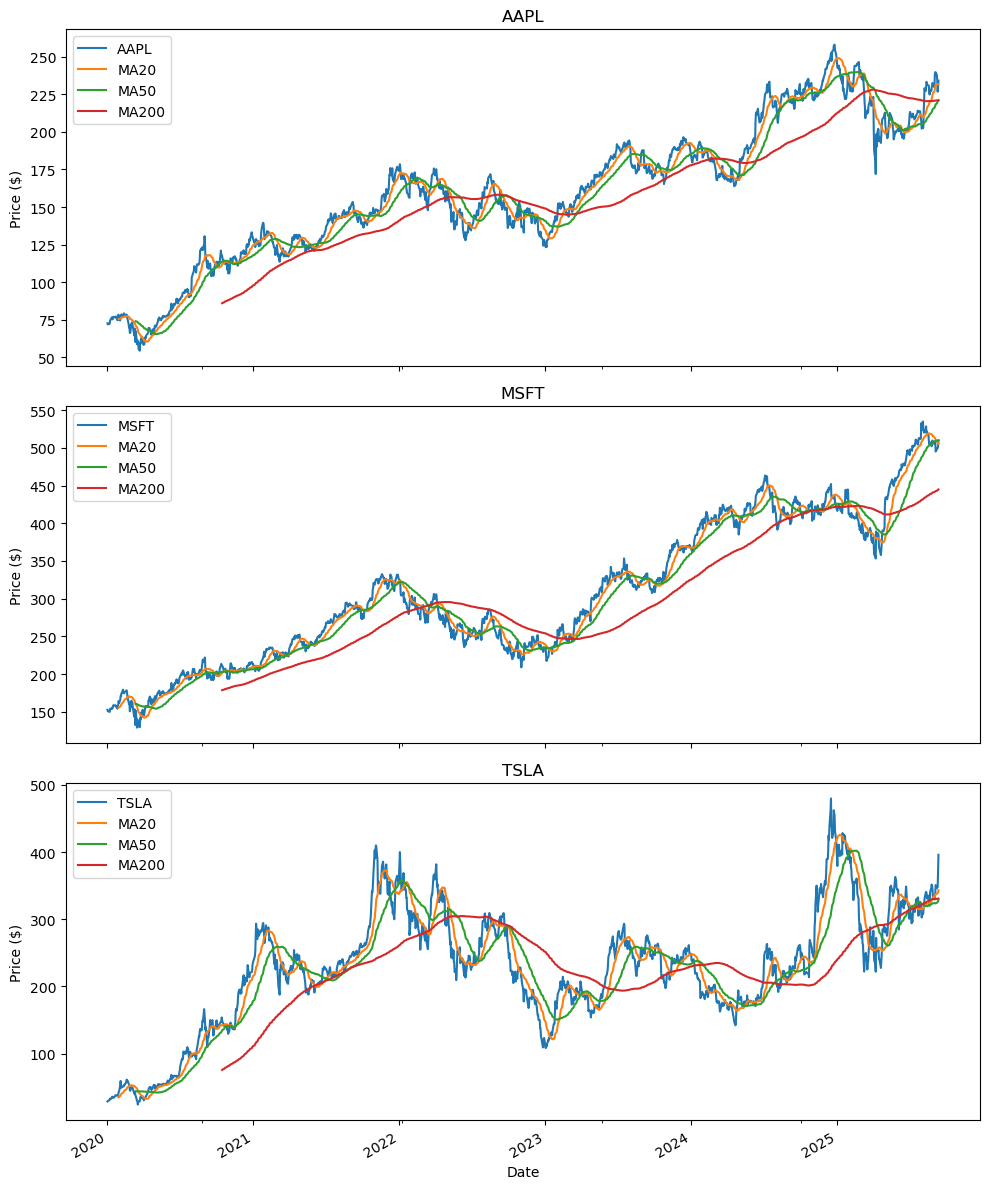

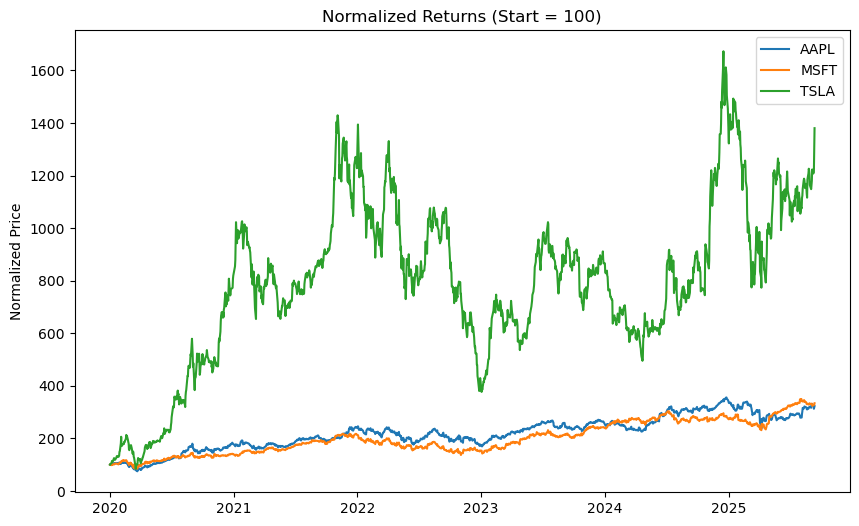

In [7]:
# Below is the stock price dashboard
import yfinance as yf
import matplotlib.pyplot as plt


#Pull
tickers = ['AAPL', 'MSFT', 'TSLA']
data = yf.download(tickers, start = "2020-01-01")['Close']

#Transform
ma_windows = [20, 50, 200]
ma_data = {t: data[t].to_frame() for t in tickers}

for t in tickers:
    for w in ma_windows:
        ma_data[t][f"MA{w}"] = data[t].rolling(window=w).mean()

#Plot
fig, axes = plt.subplots(len(tickers), 1, figsize=(10, 12), sharex=True)
for i, t in enumerate(tickers):
    ax = axes[i]
    ma_data[t].plot(ax=ax, title=t)
    ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()

# Compare with normalized returns
norm = data/data.iloc[0] * 100
plt.figure(figsize=(10, 6))
for t in tickers:
    plt.plot(norm.index, norm[t], label=t)
plt.title("Normalized Returns (Start = 100)")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

/var/folders/8m/rcncq3bj137bqg7bk01pr0xw0000gn/T/ipykernel_34063/4111063787.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  etf = yf.download(tickers="SPY")
[*********************100%***********************]  1 of 1 completed


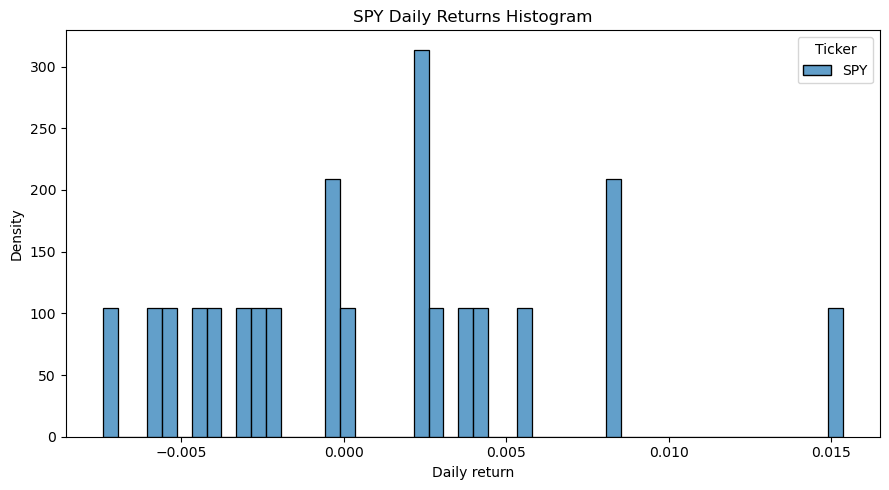

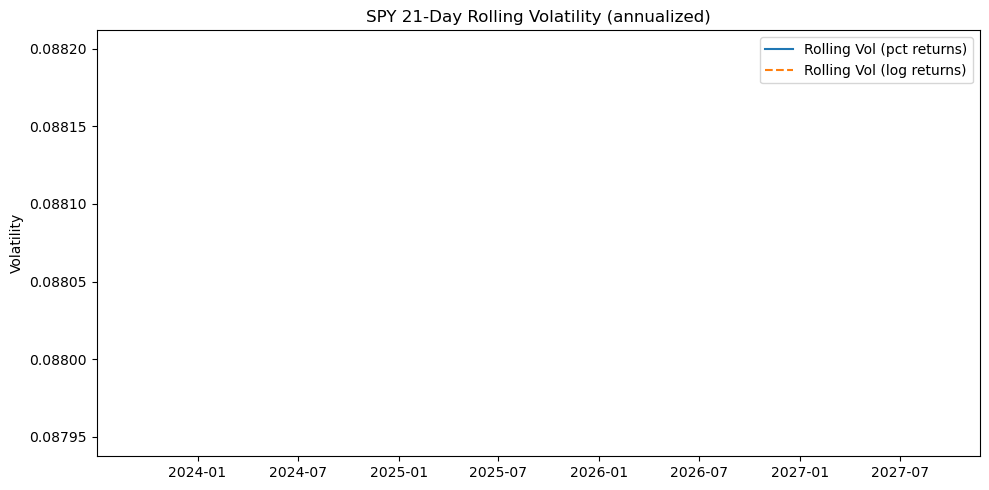

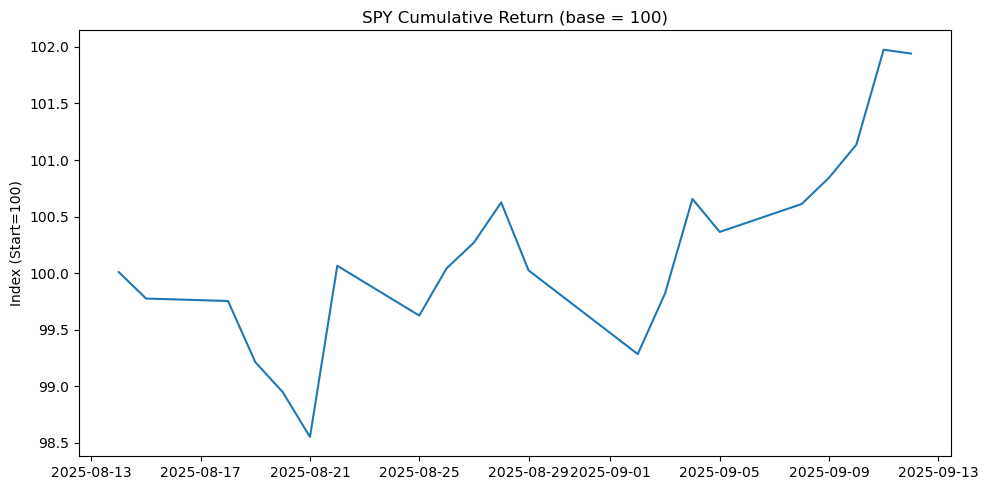

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
#Now ETF volatility and return analysis

#Pull
etf = yf.download(tickers="SPY")
price = etf['Close']

#Transform
ret = price.pct_change().dropna()

#log returns
log_ret = np.log(price / price.shift(1)).dropna()

#cumulative returns
cum_ret = (1 + ret).cumprod() - 1

# Rolling volatility annualized
win = 21
roll_vol_pct = ret.rolling(win).std() * np.sqrt(252)
roll_vol_log = log_ret.rolling(win).std() * np.sqrt(252)

#Histogram of daily returns
plt.figure(figsize=(9, 5))
sns.histplot(ret, bins=50, stat="density", alpha=0.7)
plt.title("SPY Daily Returns Histogram")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

#Rolling volatility over time
plt.figure(figsize=(10, 5))
plt.plot(roll_vol_pct.index, roll_vol_pct, label="Rolling Vol (pct returns)")
plt.plot(roll_vol_log.index, roll_vol_log, label="Rolling Vol (log returns)", linestyle="--")
plt.title(f"SPY 21-Day Rolling Volatility (annualized)")
plt.ylabel("Volatility")
plt.legend()
plt.tight_layout()
plt.show()

#Cumulative return curve
plt.figure(figsize=(10, 5))
plt.plot(cum_ret.index, (1 + cum_ret) * 100, label='SPY')
plt.title("SPY Cumulative Return (base = 100)")
plt.ylabel("Index (Start=100)")
plt.xlabel("")
plt.tight_layout()
plt.show()




In [12]:
# Sector comparison
tickers = ["XLK", "XLE", "XLF", "XLV", "XLY", "XLP", "XLI", "XLU", "XLRE", "XLB"]
data = yf.download(tickers, period="5y", auto_adjust=True)["Close"]

daily_ret = data.pct_change().dropna()

#Annualize
mean_daily = daily_ret.mean()
vol_daily = daily_ret.std()

annual_ret = (1 + mean_daily) ** 252 - 1
annual_vol = vol_daily * np.sqrt(252)
sharpe = annual_ret / annual_vol 

metrics = pd.DataFrame({
    "Annual Return": annual_ret,
    "Annual Vol": annual_vol,
    "Sharpe": sharpe
}).sort_values("Annual Return", ascending=False)

print(metrics.round(3))

[*********************100%***********************]  10 of 10 completed

        Annual Return  Annual Vol  Sharpe
Ticker                                   
XLE             0.325       0.289   1.124
XLK             0.234       0.248   0.943
XLF             0.210       0.196   1.071
XLI             0.177       0.177   1.000
XLY             0.142       0.238   0.596
XLU             0.126       0.175   0.720
XLB             0.110       0.194   0.569
XLRE            0.087       0.195   0.445
XLV             0.083       0.146   0.566
XLP             0.080       0.131   0.612


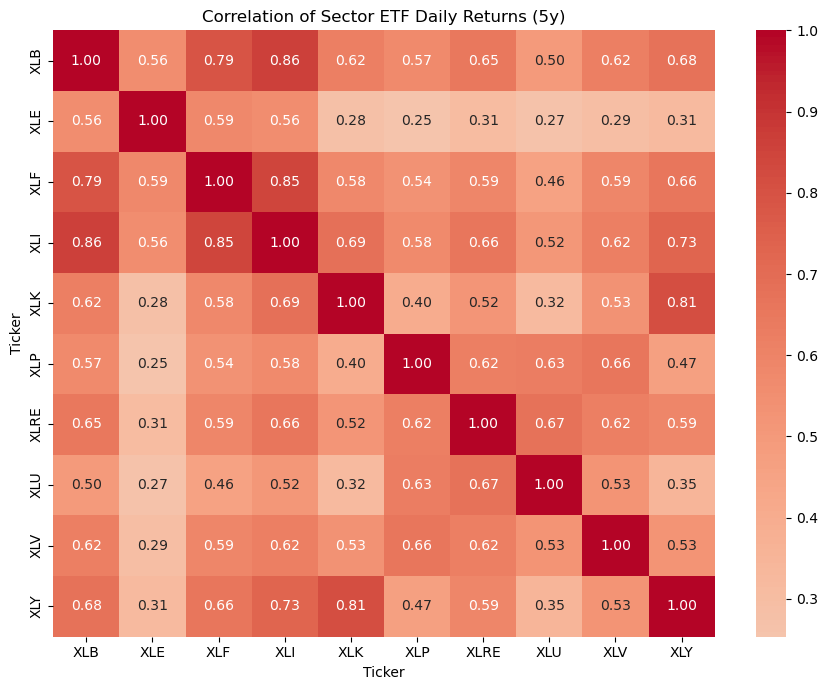

In [13]:
#First we will plot the correlation heatmap
corr = daily_ret.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Sector ETF Daily Returns (5y)")
plt.tight_layout()
plt.show()

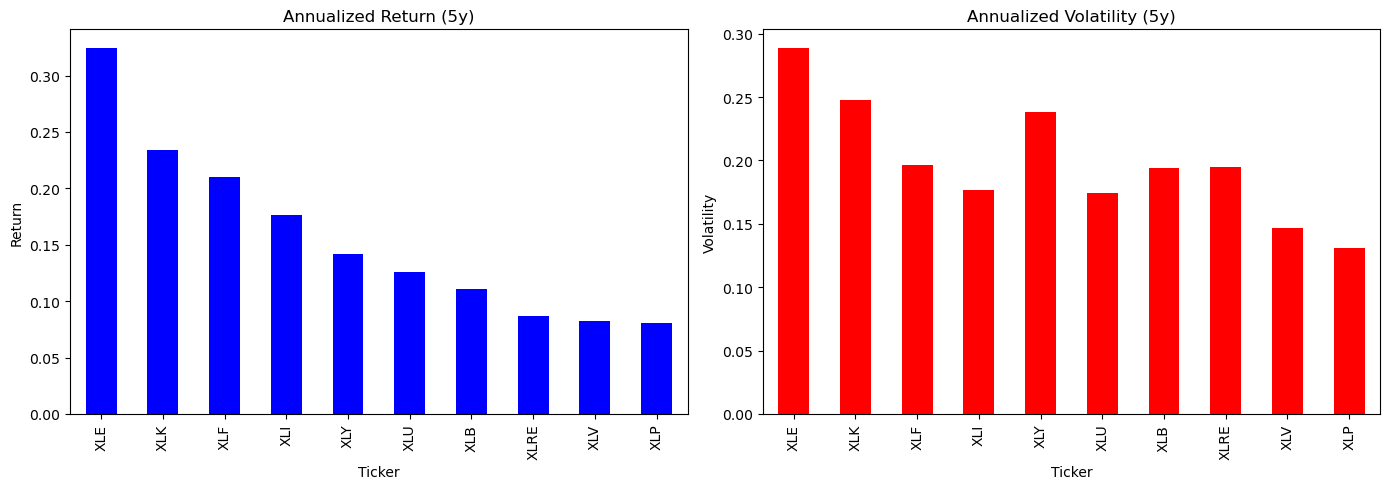

In [15]:
#Returns and volatilities
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

metrics["Annual Return"].plot.bar(ax=ax[0], color="blue")
ax[0].set_title("Annualized Return (5y)")
ax[0].set_ylabel("Return")

metrics["Annual Vol"].plot.bar(ax=ax[1], color="red")
ax[1].set_title("Annualized Volatility (5y)")
ax[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()